<a href="https://colab.research.google.com/github/allatop/networks/blob/main/_4_batchnormalization_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**



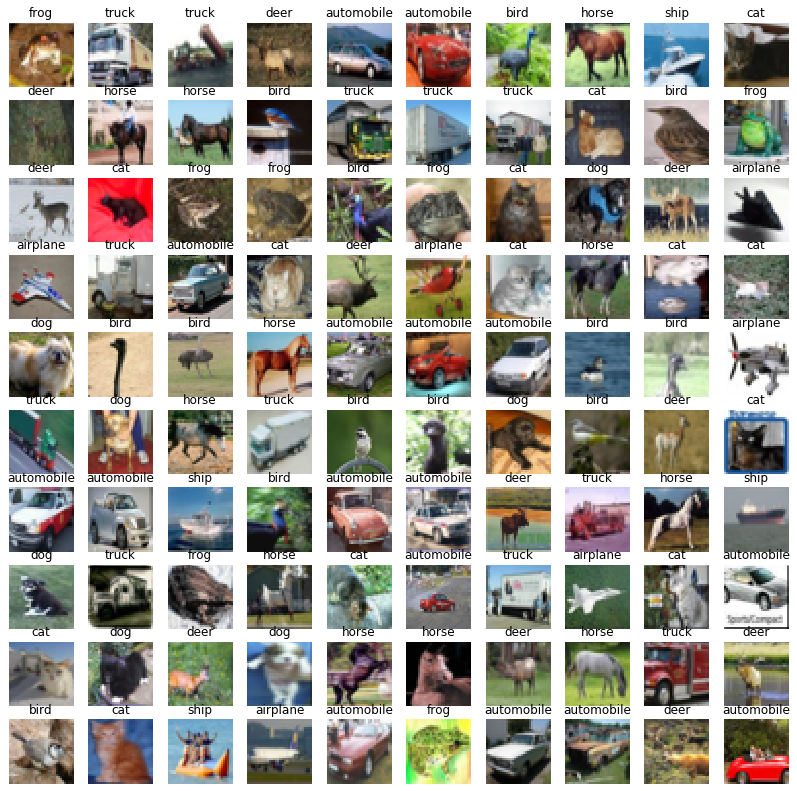

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [3]:
# 1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)

TensorFlow: 2.19.0
169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
x_train: (50000, 32, 32, 3) y_train: (50000, 1)
x_test : (10000, 32, 32, 3) y_test : (10000, 1)


### **1.2. Визуализируйте несколько изображений из датасета:**


In [2]:
drive.mount('/content/drive')

# Папка с твоими моделями (по скрину)
MODELS_DIR = "/content/drive/MyDrive/model"

# Папка с тестовыми изображениями (поменяй под свой путь)
# Структура должна быть: test/class_1/*.jpg, test/class_2/*.jpg, ...
TEST_DIR = "/content/drive/MyDrive/animals/test"   # <-- ИЗМЕНИ ПОД СЕБЯ

# Размер изображения должен совпадать с обучением
IMG_SIZE = (224, 224)   # если обучал на другом размере, замени
BATCH_SIZE = 32



Mounted at /content/drive


/tmp/ipykernel_1504/2971447631.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


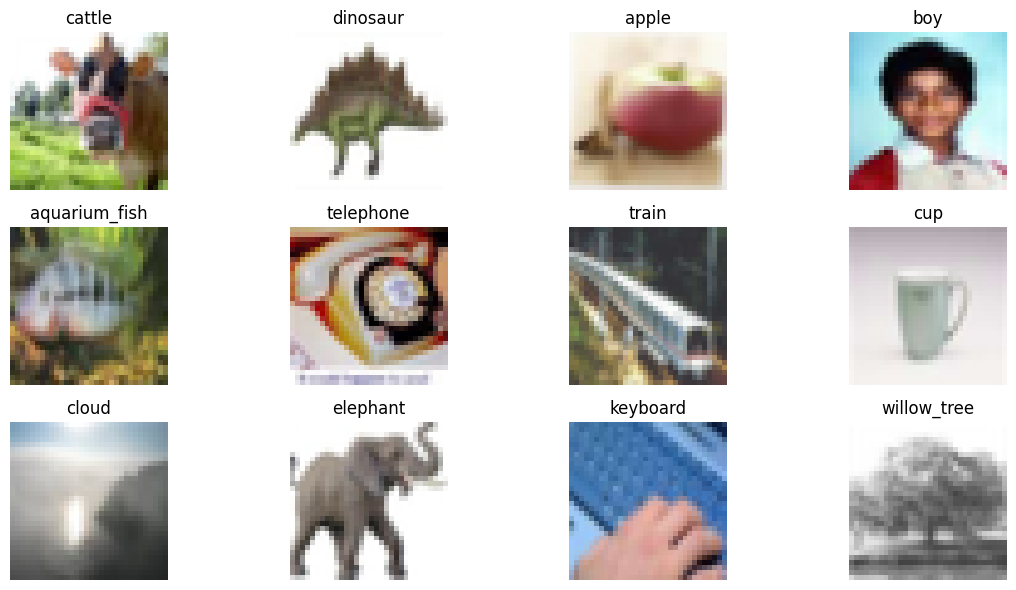

In [4]:
# 1.2. Визуализируйте несколько изображений из датасета
class_names = [
    "apple","aquarium_fish","baby","bear","beaver","bed","bee","beetle","bicycle","bottle",
    "bowl","boy","bridge","bus","butterfly","camel","can","castle","caterpillar","cattle",
    "chair","chimpanzee","clock","cloud","cockroach","couch","craб","crocodile","cup","dinosaur",
    "dolphin","elephant","flatfish","forest","fox","girl","hamster","house","kangaroo","keyboard",
    "lamp","lawn_mower","leopard","lion","lizard","lobster","man","maple_tree","motorcycle","mountain",
    "mouse","mushroom","oak_tree","orange","orchid","otter","palm_tree","pear","pickup_truck","pine_tree",
    "plain","plate","poppy","porcupine","possum","rabbit","raccoon","ray","road","rocket",
    "rose","sea","seal","shark","shrew","skunk","skyscraper","snail","snake","spider",
    "squirrel","streetcar","sunflower","sweet_pepper","table","tank","telephone","television","tiger","tractor",
    "train","trout","tulip","turtle","wardrobe","whale","willow_tree","wolf","woman","worm"
]

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [5]:
# 1.3. Произведите нормализацию данных
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print(x_train.min(), x_train.max(), x_test.min(), x_test.max())

0.0 1.0 0.0 1.0


In [6]:
# Общие параметры
num_classes = 100
input_shape = (32, 32, 3)
epochs = 20
batch_size = 64

### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [7]:
# 1.4. model_1: без BatchNormalization() и Dropout()
model_1 = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_1 = model_1.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.1401 - loss: 3.6959 - val_accuracy: 0.2138 - val_loss: 3.2618
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2871 - loss: 2.8631 - val_accuracy: 0.3259 - val_loss: 2.6820
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3744 - loss: 2.4532 - val_accuracy: 0.3745 - val_loss: 2.4625
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4326 - loss: 2.1735 - val_accuracy: 0.3830 - val_loss: 2.4298
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4781 - loss: 1.9563 - val_accuracy: 0.4169 - val_loss: 2.3168
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5268 - loss: 1.7576 - val_accuracy: 0.4131 - val_loss: 2.3552
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5671 - loss: 1.5839 - val_accuracy: 0.4217 - val_loss: 2.3789
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6071 - loss: 1.4117 - val_accuracy: 0

Обучите созданную модель

In [ ]:
# Ваш код #

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [8]:
# 1.5. model_2: с BatchNormalization()
model_2 = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(num_classes, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_2 = model_2.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.2532 - loss: 3.1169 - val_accuracy: 0.3163 - val_loss: 2.7104
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4221 - loss: 2.2275 - val_accuracy: 0.3898 - val_loss: 2.4033
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5206 - loss: 1.7979 - val_accuracy: 0.4132 - val_loss: 2.3636
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6055 - loss: 1.4537 - val_accuracy: 0.4277 - val_loss: 2.3872
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6819 - loss: 1.1383 - val_accuracy: 0.3990 - val_loss: 2.6543
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7577 - loss: 0.8477 - val_accuracy: 0.4193 - val_loss: 2.6597
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8195 - loss: 0.6167 - val_accuracy: 0.4315 - val_loss: 2.7654
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8703 - loss: 0.4407 - val_accuracy: 

Обучите созданную модель

In [ ]:
# Ваш код #

### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [9]:
# 1.6. model_3: с Dropout()
model_3 = models.Sequential([
    Input(shape=input_shape),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_3.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_3 = model_3.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.0610 - loss: 4.1702 - val_accuracy: 0.1437 - val_loss: 3.6978
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1449 - loss: 3.5968 - val_accuracy: 0.2270 - val_loss: 3.2556
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1939 - loss: 3.3145 - val_accuracy: 0.2628 - val_loss: 3.0811
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2271 - loss: 3.1467 - val_accuracy: 0.3082 - val_loss: 2.8146
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2520 - loss: 3.0113 - val_accuracy: 0.3110 - val_loss: 2.7621
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2724 - loss: 2.9113 - val_accuracy: 0.3529 - val_loss: 2.6076
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2886 - loss: 2.8272 - val_accuracy: 0.3354 - val_loss: 2.6806
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3002 - loss: 2.7649 - val_accuracy: 

Обучите созданную модель

In [ ]:
# Ваш код #

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [10]:
# 1.7. model_4: с Dropout() и BatchNormalization()
model_4 = models.Sequential([
    Input(shape=input_shape),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_4.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_4 = model_4.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.1239 - loss: 3.9521 - val_accuracy: 0.1921 - val_loss: 3.4830
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2380 - loss: 3.1210 - val_accuracy: 0.3184 - val_loss: 2.7104
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2988 - loss: 2.7974 - val_accuracy: 0.3339 - val_loss: 2.6292
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3376 - loss: 2.6009 - val_accuracy: 0.3641 - val_loss: 2.5275
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3627 - loss: 2.4828 - val_accuracy: 0.3245 - val_loss: 2.7432
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3828 - loss: 2.3792 - val_accuracy: 0.4174 - val_loss: 2.2309
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4007 - loss: 2.2970 - val_accuracy: 0.3054 - val_loss: 2.9600
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4134 - loss: 2.2215 - val_accuracy: 

Обучите созданную модель

In [ ]:
# Ваш код #

### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

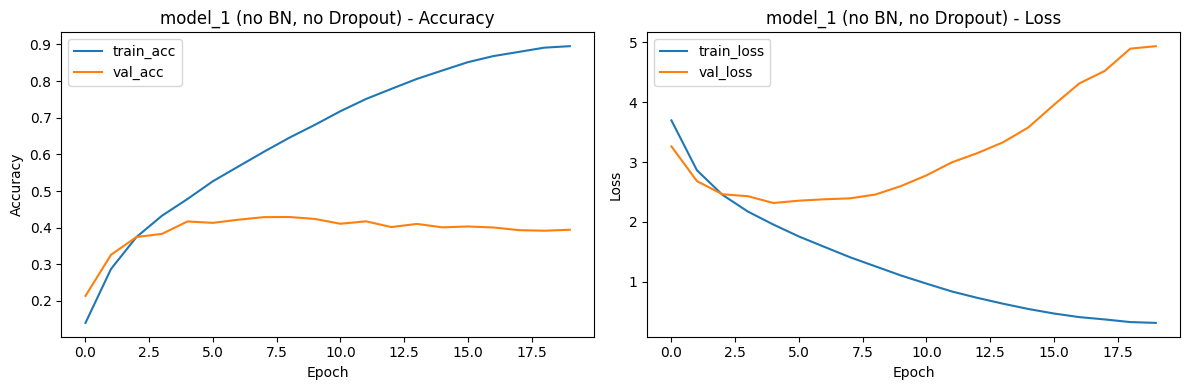

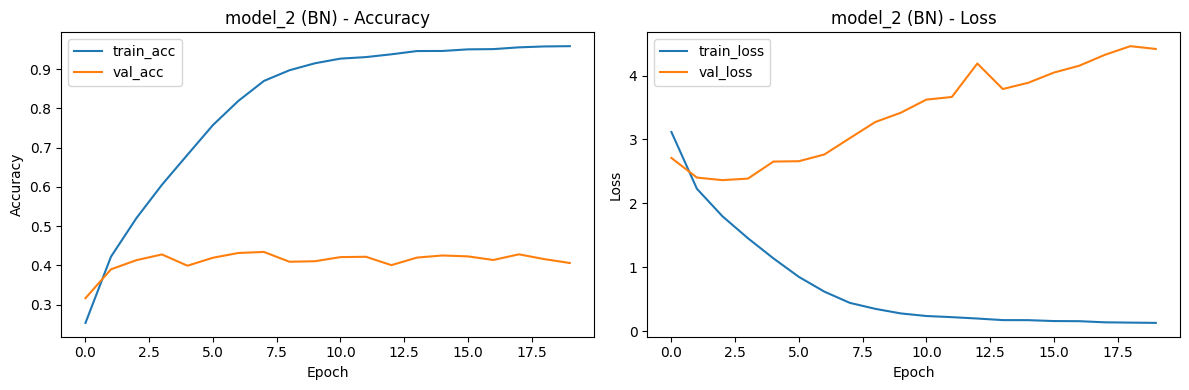

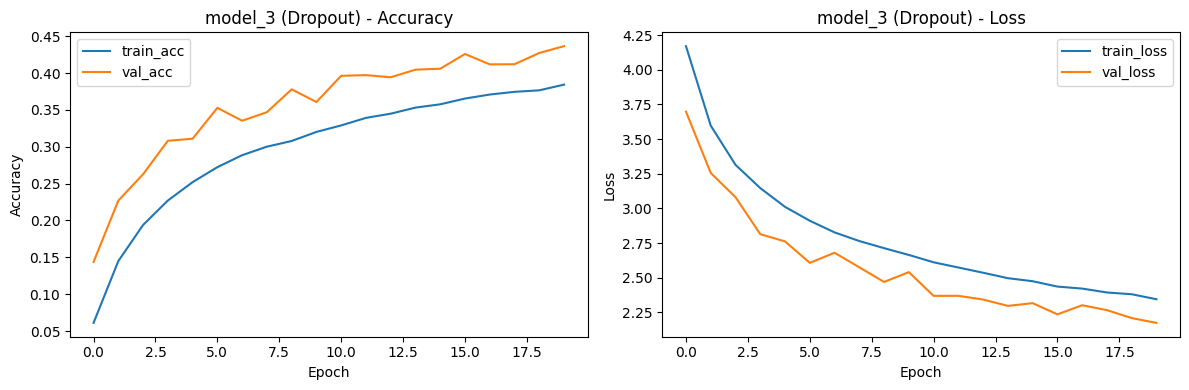

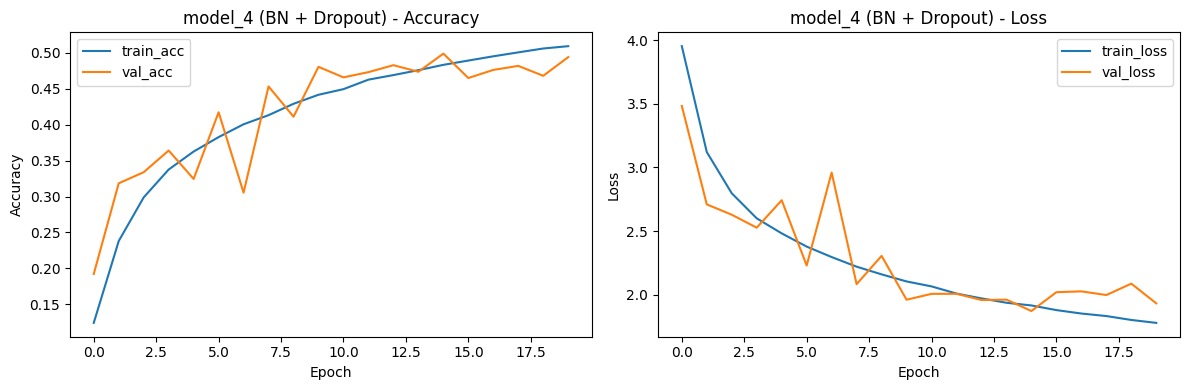

Результаты на test:
model_1: loss=4.9352, acc=0.3943
model_2: loss=4.4183, acc=0.4059
model_3: loss=2.1747, acc=0.4366
model_4: loss=1.9338, acc=0.4942


In [11]:
# 1.8. Постройте график обучения для каждой модели
def plot_history(hist, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='train_acc')
    plt.plot(hist.history['val_accuracy'], label='val_acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='train_loss')
    plt.plot(hist.history['val_loss'], label='val_loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_1, "model_1 (no BN, no Dropout)")
plot_history(history_2, "model_2 (BN)")
plot_history(history_3, "model_3 (Dropout)")
plot_history(history_4, "model_4 (BN + Dropout)")

# итоговая таблица точности
scores = {}
for name, model in [("model_1", model_1), ("model_2", model_2), ("model_3", model_3), ("model_4", model_4)]:
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    scores[name] = (loss, acc)

print("Результаты на test:")
for k,v in scores.items():
    print(f"{k}: loss={v[0]:.4f}, acc={v[1]:.4f}")

Ваши выводы

Ваш итог

### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

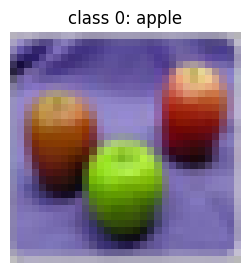

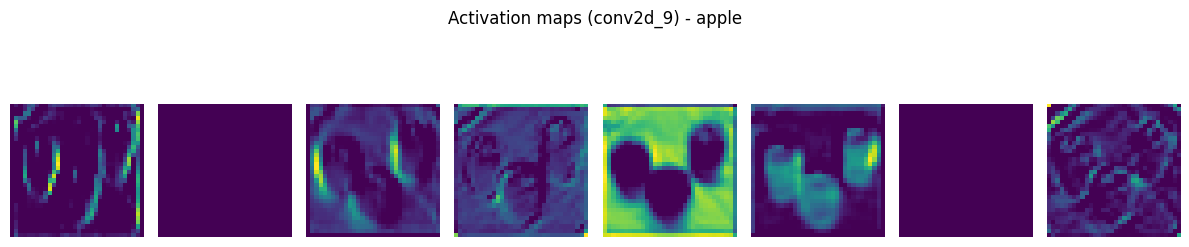

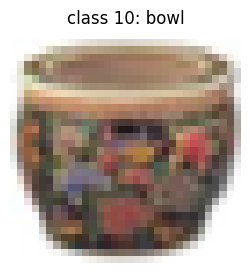

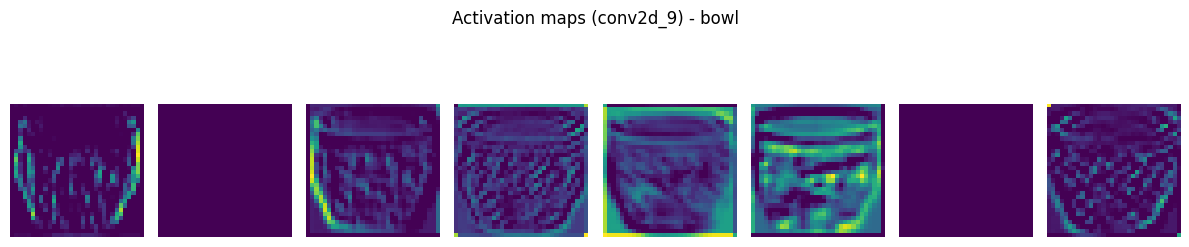

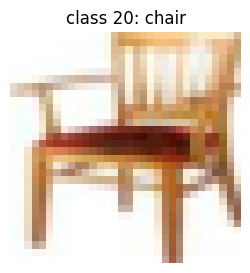

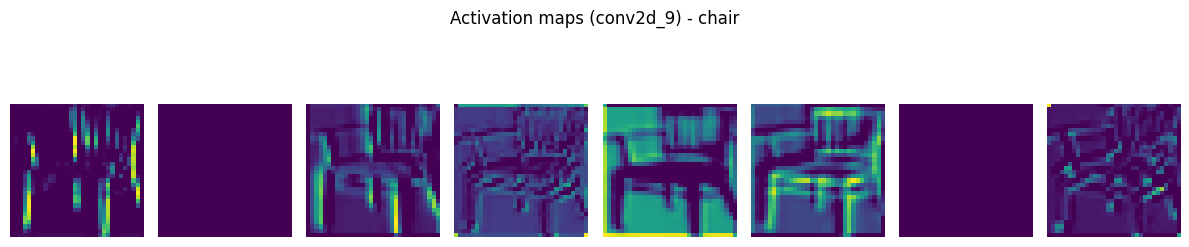

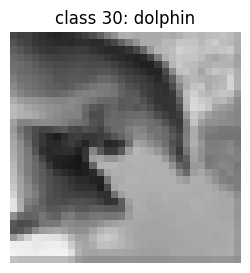

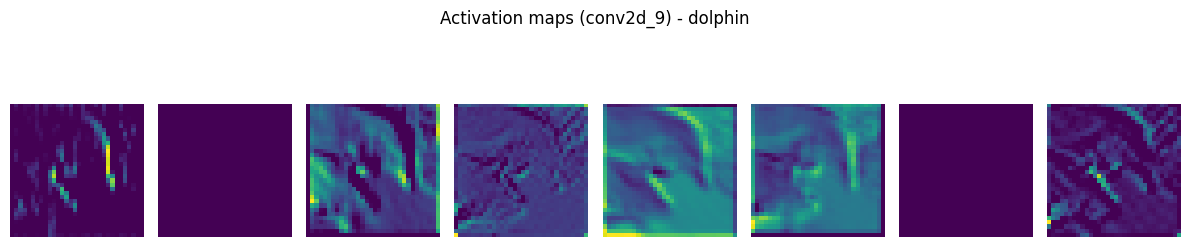

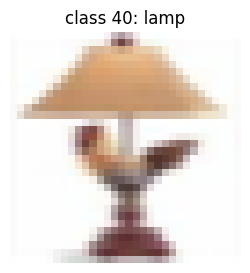

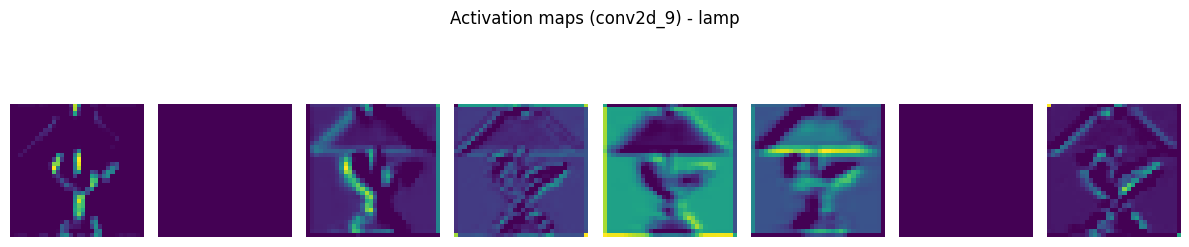

In [14]:
# 1.9. Карты активации model_4 по 5 классам (исправлено)
selected_classes = [0, 10, 20, 30, 40]

examples = {}
for i in range(len(x_test)):
    c = int(y_test[i, 0])   # было int(y_test[i]) -> warning
    if c in selected_classes and c not in examples:
        examples[c] = x_test[i]
    if len(examples) == len(selected_classes):
        break

conv_outputs = []
conv_names = []
for lyr in model_4.layers:
    if isinstance(lyr, tf.keras.layers.Conv2D):
        conv_outputs.append(lyr.output)
        conv_names.append(lyr.name)

# важно: "позвать" модель хотя бы 1 раз, чтобы точно были inputs/outputs
_ = model_4.predict(x_test[:1], verbose=0)

# для Sequential безопаснее так:
activation_model = tf.keras.Model(inputs=model_4.inputs, outputs=conv_outputs)

for c in selected_classes:
    img = examples[c]
    pred_inp = np.expand_dims(img, axis=0)
    acts = activation_model.predict(pred_inp, verbose=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"class {c}: {class_names[c]}")
    plt.axis("off")
    plt.show()

    first_map = acts[0][0]   # активации 1-го Conv2D
    n = min(8, first_map.shape[-1])

    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(first_map[:, :, i], cmap='viridis')
        plt.axis("off")
    plt.suptitle(f"Activation maps ({conv_names[0]}) - {class_names[c]}")
    plt.tight_layout()
    plt.show()

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

In [15]:
!curl -L -o animal-image-datasetdog-cat-and-panda.zip \
  https://www.kaggle.com/api/v1/datasets/download/ashishsaxena2209/animal-image-datasetdog-cat-and-panda


!unzip -q animal-image-datasetdog-cat-and-panda.zip -d dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  375M  100  375M    0     0  58.1M      0  0:00:06  0:00:06 --:--:-- 42.5M


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

DATASET_DIR = "dataset/animals/animals"  # после unzip обычно так
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Классы:", class_names)
print("Количество классов:", num_classes)

Found 3000 files belonging to 3 classes.
Using 2400 files for training.
Found 3000 files belonging to 3 classes.
Using 600 files for validation.
Классы: ['cats', 'dogs', 'panda']
Количество классов: 3


In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
test_ds  = test_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [18]:
model_bn_do = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_bn_do.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn_do = model_bn_do.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    verbose=1
)

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - accuracy: 0.6179 - loss: 1.0938 - val_accuracy: 0.3467 - val_loss: 13.1442
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.6612 - loss: 0.8200 - val_accuracy: 0.3467 - val_loss: 6.9309
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.7054 - loss: 0.6978 - val_accuracy: 0.3200 - val_loss: 5.6148
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7467 - loss: 0.5834 - val_accuracy: 0.3200 - val_loss: 3.8297
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.7808 - loss: 0.4938 - val_accuracy: 0.3350 - val_loss: 3.1572
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8292 - loss: 0.4010 - val_accuracy: 0.4050 - val_loss: 2.3361
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.7979 - loss: 0.4707 - val_accuracy: 0.5617 - val_loss: 1.1337
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.8079 - loss: 0.4410 - val_accuracy:

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Загружена старая модель: /content/drive/MyDrive/model/animal_model_final.keras
Found 3000 files belonging to 3 classes.
Using 600 files for validation.

Сравнение на тесте:
new_bn_dropout (224x224):         loss=2.5525, acc=0.4650
animal_model_final (128x128 flat): loss=0.8134, acc=0.6400


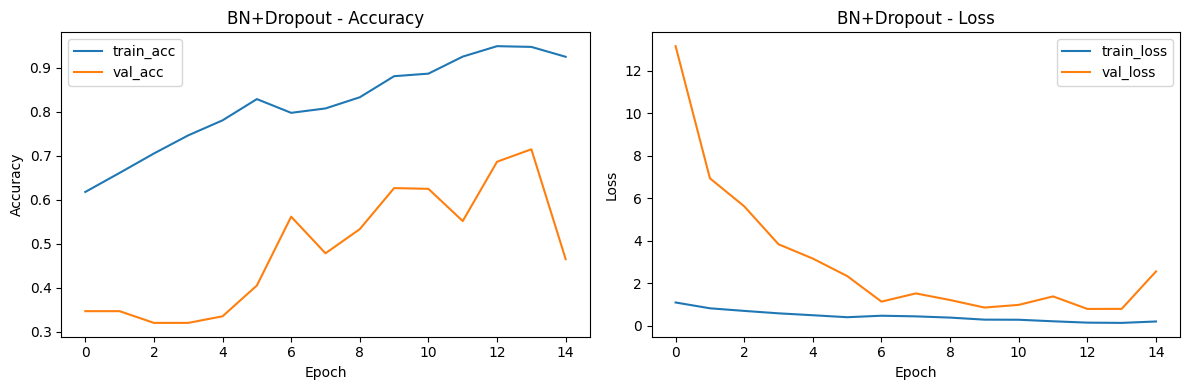

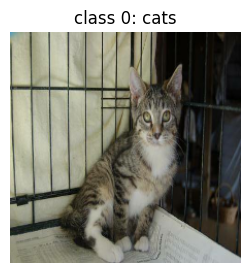

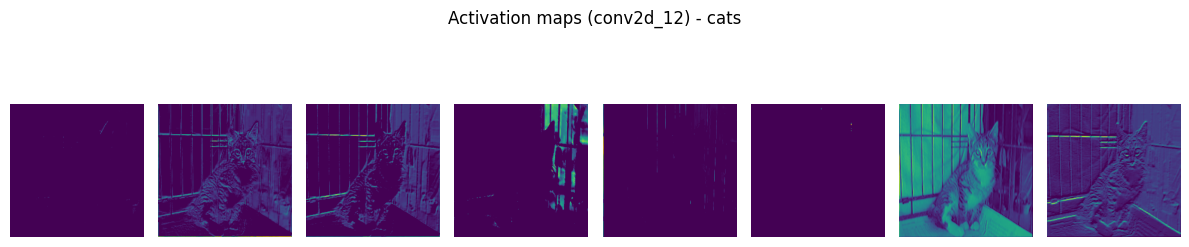

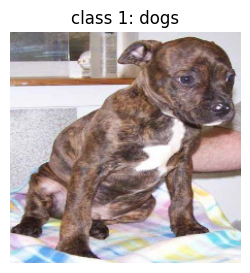

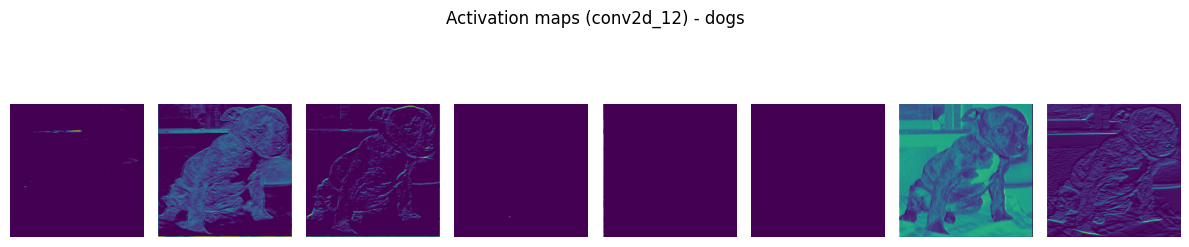

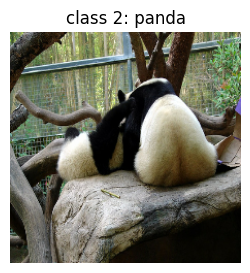

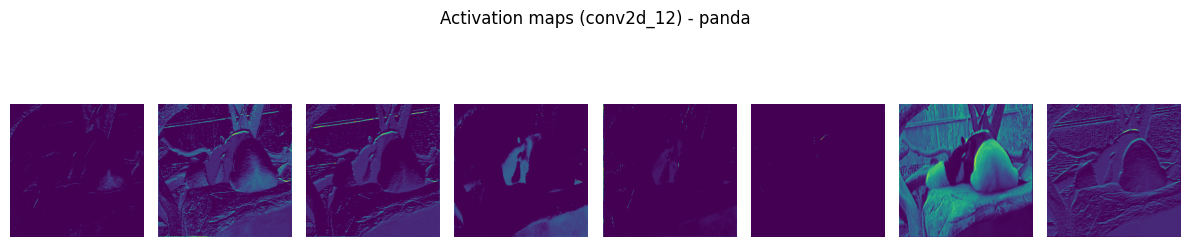

In [23]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
SEED = 42
BATCH_SIZE = 32
NUM_CLASSES = 3


DATASET_DIR = "dataset/animals/animals"
OLD_MODEL_PATH = "/content/drive/MyDrive/model/animal_model_final.keras"
old_model = tf.keras.models.load_model(OLD_MODEL_PATH)
print("Загружена старая модель:", OLD_MODEL_PATH)


loss_new, acc_new = model_bn_do.evaluate(test_ds_new, verbose=0)
loss_old, acc_old = old_model.evaluate(test_ds_old, verbose=0)

print("\nСравнение на тесте:")
print(f"new_bn_dropout (224x224):         loss={loss_new:.4f}, acc={acc_new:.4f}")
print(f"animal_model_final (128x128 flat): loss={loss_old:.4f}, acc={acc_old:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_bn_do.history['accuracy'], label='train_acc')
plt.plot(history_bn_do.history['val_accuracy'], label='val_acc')
plt.title('BN+Dropout - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_bn_do.history['loss'], label='train_loss')
plt.plot(history_bn_do.history['val_loss'], label='val_loss')
plt.title('BN+Dropout - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


selected_classes = list(range(NUM_CLASSES))  # [0,1,2]

examples = {}
for bx, by in test_ds_new:
    for i in range(len(by)):
        c = int(by[i].numpy())
        if c not in examples:
            examples[c] = bx[i].numpy()
    if len(examples) == NUM_CLASSES:
        break

conv_outputs = []
conv_names = []

activation_model = tf.keras.Model(inputs=model_bn_do.inputs, outputs=conv_outputs)

for c in selected_classes:
    img = examples[c]
    inp = np.expand_dims(img, axis=0)
    acts = activation_model.predict(inp, verbose=0)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"class {c}: {class_names[c]}")
    plt.axis("off")
    plt.show()

    first_map = acts[0][0]   # активации 1-го Conv слоя
    n_maps = min(8, first_map.shape[-1])

    plt.figure(figsize=(12,3))
    for i in range(n_maps):
        plt.subplot(1, n_maps, i+1)
        plt.imshow(first_map[:, :, i], cmap='viridis')
        plt.axis("off")
    plt.suptitle(f"Activation maps ({conv_names[0]}) - {class_names[c]}")
    plt.tight_layout()
    plt.show()